# Periods and flux vacua in JAXVacua: a live demo

**What's in this notebook?** This notebook is the live-demo companion to *Toric methods for Calabi--Yau compactifications and the string landscape*, lecture 2. It walks through the way [JAXVacua](https://arxiv.org/abs/2306.06160) packages periods and flux vacua of the Type IIB orientifold EFT, exercises the API on two qualitatively different prepotentials, and is honest about the regime of validity of each.

The bulk of the notebook reproduces the **Demirtas--Kim--McAllister--Moritz (DKMM) two-modulus perturbatively flat vacuum** at large complex structure ([arXiv:1912.10047](https://arxiv.org/abs/1912.10047)):

1. **fetching the polytope** of the canonical $h^{1,1}=2$, $h^{2,1}=272$ Calabi--Yau threefold from the Kreuzer--Skarke database via `CYTools`, in a divisor basis where the Mori cone is the positive orthant;
2. **building two `FluxEFT` objects** — one from CYTools data via the `cytools_interface`, one from the stored `model_ID=1` distributed with `JAXVacua` — and **asserting that their topological data (intersection numbers, $c_2$, the prepotential $a$-matrix, and the linear $b$-vector) agree**, so the demo is auditable;
3. **constructing the full symplectic flux vector** from the PFV data $M=(-16,50),\ K=(3,-4)$, after explicitly checking the PFV integrality conditions $R_a=\widetilde a_{ab}M^b\in\mathbb Z$ and $R_0=\tfrac{1}{24}M^a\widetilde c_a\in\mathbb Z$ from the model's own stored prepotential data;
4. **solving the F-term equations** $D_iW=0$, $D_\tau W=0$ to recover the supersymmetric PFV solution numerically, with explicit assertions on $|W_0|$, $|DW|$, and the D3 tadpole;
5. **identifying the racetrack** of \eqref{eq:racetrack} explicitly: extracting the leading exponents $p_1,p_2$ (rationals, not integers — cf.\ the lecture) and the prefactors $c,A$ from the leading mirror GV invariants, and verifying $|W_0|\sim|c|\,|c/A|^{p_1/(p_2-p_1)}$.

The closing section then leaves LCS and **demonstrates the same `DW_x` / `dDW_x` Newton machinery on a closed-form non-LCS prepotential**, the $X_{3,3}$ K-point of [arXiv:2306.01059](https://arxiv.org/abs/2306.01059). The point is to make visible (a) what part of the JAXVacua API is generic — any user-supplied jit-safe prepotential plugs in via `prepotential_input=` — and (b) what is LCS-specific — the DKMM PFV theorem, `pfv_to_flux`, the racetrack formula, and the GV worldsheet-instanton tower do not carry over.

**Primary references:** Demirtas--Kim--McAllister--Moritz, *Vacua with Small Flux Superpotential*, [arXiv:1912.10047](https://arxiv.org/abs/1912.10047); the JAXVacua release paper [arXiv:2306.06160](https://arxiv.org/abs/2306.06160).

**Companion references:** computational mirror symmetry [arXiv:2303.00757](https://arxiv.org/abs/2303.00757); hypergeometric Calabi--Yau models [arXiv:2306.01059](https://arxiv.org/abs/2306.01059); TASI 2024 lectures [arXiv:2512.17095](https://arxiv.org/abs/2512.17095).

(*Created:* Andreas Schachner)

## Imports and environment

We follow the JAXVacua tutorial convention: `jax_enable_x64=True` (the prepotential and its derivatives must be computed in double precision), CYTools loaded for the toric input, and the standard plotting toolkit at the ready for the racetrack landscape at the end.

In [1]:
# General imports
import warnings, time, sys, os
import numpy as np
from scipy.optimize import root
from IPython.display import Image


# JAX imports
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

# Plotting
import matplotlib.pyplot as plt
import seaborn as sn

# JAXVacua and CYTools
import jaxvacua as jvc
from cytools import fetch_polytopes

# Project-local: keep the demo defensive but visible
warnings.filterwarnings("once")  # show each warning once, do not silence everything

print(f"jax backend: {jax.default_backend()}")
print(f"jaxvacua precision: {jvc.precision}")

jax backend: cpu
jaxvacua precision: float64


## The geometry: $h^{1,1}=2$, $h^{2,1}=272$ Calabi--Yau threefold

The DKMM example of [arXiv:1912.10047](https://arxiv.org/abs/1912.10047) uses the Calabi--Yau hypersurface $X$ in $\mathbb{P}^4_{1,1,1,6,9}[18]$ with $(h^{1,1}(X), h^{2,1}(X)) = (2, 272)$. The two-modulus effective description lives on the $G=\mathbb{Z}_6\times\mathbb{Z}_{18}$-invariant sublocus of $\mathcal M_{\rm cs}(X)$ introduced by Giryavets--Kachru--Tripathy--Trivedi ([hep-th/0312104](https://arxiv.org/abs/hep-th/0312104)), on which the periods coincide with those of the Greene--Plesser mirror.

We fetch the polytope directly from the Kreuzer--Skarke list via `CYTools.fetch_polytopes`. In the convention of [JAXVacua](https://arxiv.org/abs/2306.06160), `cy` represents the **mirror** Calabi--Yau on whose Kähler-moduli space the relevant prepotential lives, so the index `cy.h11() = 2` is the number of effective complex structure moduli on the symmetric sublocus.

In [35]:
p = fetch_polytopes(h11=2, h12=272, limit=5, lattice="N", as_list=True)[0]
cy = p.triangulate().get_cy()

print(f"Data for the mirror CY (degree 18 hypersurface in CP[1,1,1,6,9]):")
print(f"h^(1,1)(cy) = {cy.h11()}")
print(f"h^(2,1)(cy) = {cy.h12()}")
print(f"chi(cy)     = {cy.chi()}")
print(f"intersection numbers (in CYTools basis): {cy.intersection_numbers(in_basis=True, format='dense').tolist()}")
print(f"c_2 . D_a (in CYTools basis): {cy.second_chern_class(in_basis=True)}")

Data for the mirror CY (degree 18 hypersurface in CP[1,1,1,6,9]):
h^(1,1)(cy) = 2
h^(2,1)(cy) = 272
chi(cy)     = -540
intersection numbers (in CYTools basis): [[[0, 1], [1, -3]], [[1, -3], [-3, 9]]]
c_2 . D_a (in CYTools basis): [36 -6]


## A short detour: timing the GV computation

Genus-zero Gopakumar--Vafa invariants are the integer enumerative invariants of effective curve classes on the mirror, obtained from the genus-zero Gromov--Witten generating function by the multiple-cover resummation of [arXiv:hep-th/9809187](https://arxiv.org/abs/hep-th/9809187). They control every instanton term in the racetrack expansion below, so their cost sets the practical truncation degree for any large-scale PFV scan. [CYTools](https://cy.tools) computes them via a recent fast intersection-number kernel, and it is worth seeing how the runtime and the number of returned invariants scale with the truncation degree before proceeding.

In [3]:
gvs = cy.compute_gvs(max_deg=10)
gvs

N=65 gv-invariants calculated for a Calabi-Yau 3-fold hypersurface with h11=2 and h21=272 in a 4-dimensional toric variety using grading_vec=[4 1] and cutoff=10

Even at $\mathrm{max\_deg}=10$ the GV table is already moderately large. To map out the scaling, we vary $\mathrm{max\_deg}\in\{10,20,\dots,60\}$ and record, at each step, the number of non-vanishing invariants and the elapsed time.

In [43]:
dat = []
all_gvs = []
r1 = np.arange(1,10)
r2 = np.arange(10,61,10)
for deg in np.concatenate([r1, r2]):
    start = time.time()
    gvs = cy.compute_gvs(max_deg=deg)
    end = time.time()
    print(f"max_deg={deg}: {len(gvs.dok)} GVs computed in {end-start:.2f} seconds")
    print(f"largest GV invariant: {np.max(np.abs(gvs.coo[:,-1]))}",end="\n ------------ \n")
    dat.append([deg, len(gvs.dok), end-start])
    all_gvs.append([deg, gvs])
    
dat = np.array(dat)

max_deg=1: 2 GVs computed in 0.09 seconds
largest GV invariant: 540
 ------------ 
max_deg=2: 5 GVs computed in 0.09 seconds
largest GV invariant: 1080
 ------------ 
max_deg=3: 9 GVs computed in 0.09 seconds
largest GV invariant: 143370
 ------------ 
max_deg=4: 14 GVs computed in 0.09 seconds
largest GV invariant: 204071184
 ------------ 
max_deg=5: 20 GVs computed in 0.10 seconds
largest GV invariant: 21772947555
 ------------ 
max_deg=6: 27 GVs computed in 0.10 seconds
largest GV invariant: 1076518252152
 ------------ 
max_deg=7: 35 GVs computed in 0.10 seconds
largest GV invariant: 33381348217290
 ------------ 
max_deg=8: 44 GVs computed in 0.09 seconds
largest GV invariant: 31128163315047072
 ------------ 
max_deg=9: 54 GVs computed in 0.10 seconds
largest GV invariant: 8211715737128556480
 ------------ 
max_deg=10: 65 GVs computed in 0.10 seconds
largest GV invariant: 1028507105335081958010
 ------------ 
max_deg=20: 230 GVs computed in 0.17 seconds
largest GV invariant: 2945028

The two plots below summarise the benchmark: the number of GV invariants returned by CYTools and the wall-clock time taken to compute them, both on a logarithmic vertical axis against $\mathrm{max\_deg}$. The ratio of cost per invariant fixes the practical truncation degree for the downstream PFV computations.

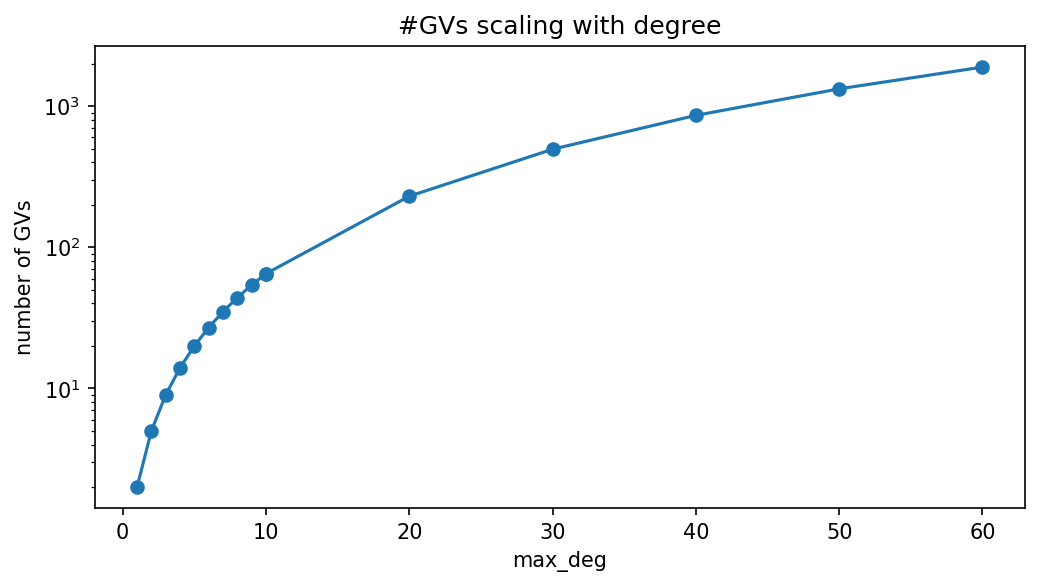

In [38]:
fig = plt.figure(figsize=(8,4),dpi=150)
plt.plot(dat[:,0], dat[:,1], marker='o', label="GVs computed")
plt.xlabel("max_deg")
plt.ylabel("number of GVs")
plt.yscale("log")
plt.title(f"#GVs scaling with degree")
plt.show()

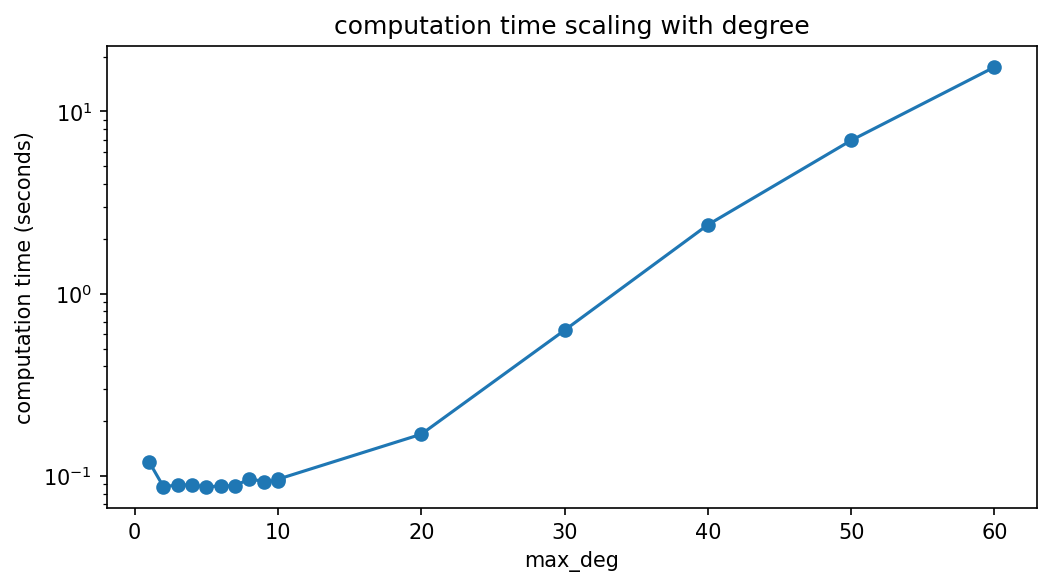

In [39]:
fig = plt.figure(figsize=(8,4),dpi=150)
plt.plot(dat[:,0], dat[:,2], marker='o', label="computation time")
plt.xlabel("max_deg")
plt.ylabel("computation time (seconds)")
plt.yscale("log")
plt.title(f"computation time scaling with degree")
plt.show()

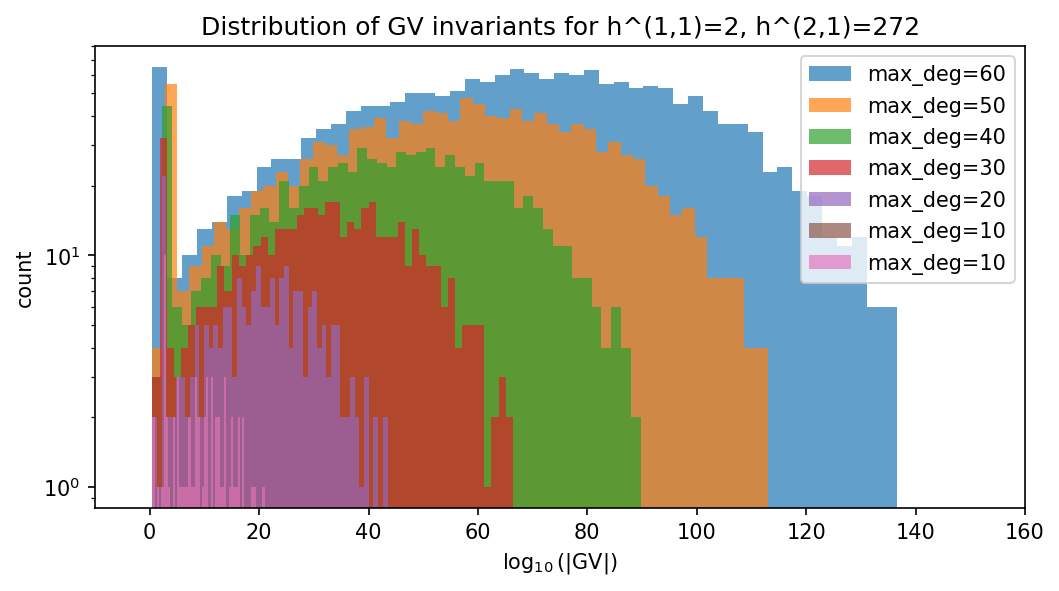

In [41]:
import math
fig = plt.figure(figsize=(8,4),dpi=150)

for deg, gvs in all_gvs[::-1]:
    if deg<10:
        continue
    # plot data
    plt.hist(list(map(lambda x: math.log10(abs(x)), gvs.dok.values())), bins=50, alpha=0.7, label=f"max_deg={deg}")
        
plt.xlabel(r"$\log_{10}(|\text{GV}|)$")
plt.ylabel("count")
plt.yscale("log")
plt.legend()
plt.title(f"Distribution of GV invariants for h^(1,1)={cy.h11()}, h^(2,1)={cy.h12()}")
plt.xlim(-10,160)
plt.show()

### Comparison with earlier benchmarks

For reference, the plot below reproduces a scaling study from an earlier benchmark run on this geometry. Absolute timings and GV counts shift with hardware, compiler, and CYTools version, so the numbers should not be compared directly with those obtained above; only the qualitative growth of both curves with $\mathrm{max\_deg}$ is meant to be read off.

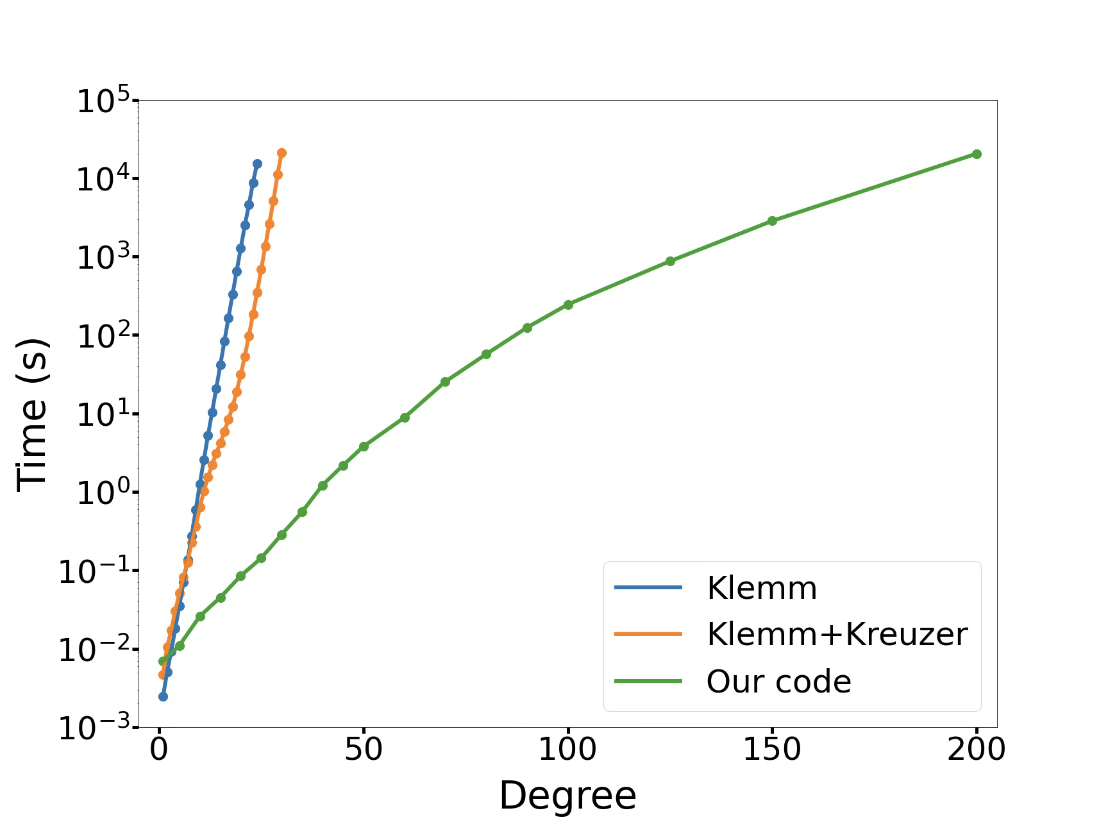

In [8]:
Image(filename='scaling_degree.png', width=800, height=600) 

In [9]:
#Image(filename='charge_sites.png', width=600, height=400) 

### Summary and handoff

The benchmarks above show that, on a laptop, CYTools comfortably reaches $\mathrm{max\_deg}\sim 50$ for this $h^{1,1}=2$ geometry, with the wall-clock time remaining manageable well past the regime needed for the PFV construction. Because the racetrack superpotential entering \eqref{eq:F-inst} is precisely the GV sum just computed, the achievable truncation depth directly bounds the precision to which $|W_0|$ can be evaluated at a candidate PFV solution. For the DKMM-style vacuum targeted next, the values of $z^a=p^a\tau$ encountered in practice are deep enough in the large-volume regime that even modest truncations suffice, with higher $\mathrm{max\_deg}$ reserved for residual-error estimates. With the GV data in hand, the FluxEFT can now be assembled and the perturbatively flat vacuum located numerically.

## Constructing the `FluxEFT` from CYTools data and finding the PFV solution

JAXVacua can build the same `FluxEFT` by feeding the `cy` object through `cytools_interface`. The two constructions should agree on every topological invariant. We build both and **assert** that they do.

The `basis_change` argument transforms the divisor basis so that the Mori cone becomes the positive orthant; this is the canonical basis used in [1912.10047](https://arxiv.org/abs/1912.10047), [2306.06160](https://arxiv.org/abs/2306.06160), and [2501.03984](https://arxiv.org/abs/2501.03984).

In [10]:
mcap = cy.mori_cone_cap(in_basis=True)
Kcup = mcap.dual_cone()
basis_change = Kcup.extremal_rays()

print(f"basis_change (extremal rays of dual Mori cone):\n{basis_change}")

model = jvc.FluxEFT(
    h12=cy.h11(),
    Q=cy.h11() + cy.h12() + 2,
    model_type="KS",
    maximum_degree=10,
    use_cytools=True,
    mirror_cy=cy,
    basis_change=basis_change,
)

basis_change (extremal rays of dual Mori cone):
[[3 1]
 [1 0]]


/opt/anaconda3/envs/cytools-dev-jax/lib/python3.13/site-packages/osqp/interface.py:290: DeprecationWarning: "polish" is deprecated. Please use "polishing" instead.
  warnings.warn(
/opt/anaconda3/envs/cytools-dev-jax/lib/python3.13/site-packages/osqp/interface.py:405: PendingDeprecationWarning: The default value of raise_error will change to True in the future.
  warnings.warn(
/opt/anaconda3/envs/cytools-dev-jax/lib/python3.13/site-packages/osqp/interface.py:73: PendingDeprecationWarning: Direct access to osqp status values will be deprecated. Please use the SolverStatus enum instead.
  warnings.warn(


Following the perturbatively flat vacuum construction (lecture 2, eq.~\eqref{eq:L2-PFV-flux-ansatz}), in the integral symplectic period basis the flux vectors take the form
$$
\vec f=(R_0,\,R_a,\,0,\,M^a)^\top, \qquad
\vec h=(0,\,K_a,\,0,\,\mathbf 0)^\top,
$$
with the integer constraints
$$
R_a=\widetilde a_{ab}M^b\in\mathbb Z, \qquad
R_0=\widetilde b_a M^a\in\mathbb Z, \qquad \widetilde b_a := \widetilde c_a/24.
$$
We use the prepotential data $(\widetilde a_{ab},\widetilde b_a)$ that JAXVacua actually feeds into `pfv_to_flux` (i.e.\ `model.lcs_tree.a_matrix` and `model.lcs_tree.b_vector` — which the audit cell has just shown match between the CYTools-built and stored models). For convenience we also display the case-piecewise hand-derivation from \eqref{eq:L2-a-ab} side-by-side.

DKMM choose $M=(-16,50)$, $K=(3,-4)$. We **first verify the integrality conditions explicitly**, **then** call `model.pfv_to_flux` to assemble the 12-component flux vector and confirm round-trip consistency.

In [11]:
M_flux = jnp.array([-16.0, 50.0])
K_flux = jnp.array([3.0, -4.0])
M = np.asarray(M_flux)

# The actual prepotential data fed into pfv_to_flux.
a_mat_model = np.asarray(model.lcs_tree.a_matrix)
b_vec_model = np.asarray(model.lcs_tree.b_vector)
kappa       = np.asarray(model.lcs_tree.intnums)

# For reference, recompute the case-piecewise hand-derivation from kappa (lecture eq:L2-a-ab).
h = kappa.shape[0]
a_mat_lecture = np.zeros((h, h))
for a in range(h):
    for b in range(h):
        if a >= b:
            a_mat_lecture[a, b] = 0.5 * kappa[a, a, b]
        else:
            a_mat_lecture[a, b] = 0.5 * kappa[a, b, b]

# R_a, R_0 from the stored matrices (this is what pfv_to_flux uses).
R_vec_predicted = a_mat_model.T @ M
R_0_predicted   = b_vec_model @ M

print(f"a_matrix (model.lcs_tree.a_matrix) =\n{a_mat_model}")
print(f"a_matrix (lecture eq:L2-a-ab, for reference) =\n{a_mat_lecture}")
print(f"b_vector (model.lcs_tree.b_vector) = {b_vec_model}")
print(f"R_a = (a^T M)_a       = {R_vec_predicted}   (must be integer)")
print(f"R_0 = b_a M^a         = {R_0_predicted}     (must be integer)")

assert np.allclose(R_vec_predicted, np.round(R_vec_predicted)), (
    "PFV integrality FAILS on R_a; choose a different (M, K).")
assert np.isclose(R_0_predicted, round(R_0_predicted)), (
    "PFV integrality FAILS on R_0; choose a different (M, K).")
print("PFV integrality conditions satisfied.")

a_matrix (model.lcs_tree.a_matrix) =
[[4.5 1.5]
 [1.5 0. ]]
a_matrix (lecture eq:L2-a-ab, for reference) =
[[4.5 0.5]
 [0.5 0. ]]
b_vector (model.lcs_tree.b_vector) = [4.25 1.5 ]
R_a = (a^T M)_a       = [  3. -24.]   (must be integer)
R_0 = b_a M^a         = 7.0     (must be integer)
PFV integrality conditions satisfied.


In [12]:
ff_solution = model.pfv_to_flux(M_flux, K_flux)
expected_flux = jnp.array(
    [R_0_predicted, R_vec_predicted[0], R_vec_predicted[1], 0.0,
     -16.0, 50.0,
     0.0, 3.0, -4.0, 0.0, 0.0, 0.0]
)

print(f"full flux vector       = {np.asarray(ff_solution)}")
print(f"hand-built expected    = {np.asarray(expected_flux)}")
print(f"round-trip pfv_to_flux → flux_to_pfv =",
      tuple(np.asarray(x) for x in model.flux_to_pfv(ff_solution)))

assert np.allclose(np.asarray(ff_solution), np.asarray(expected_flux)), (
    "JAXVacua pfv_to_flux disagrees with the hand-built PFV flux vector.")
print("pfv_to_flux output matches the PFV theorem prediction.")

full flux vector       = [  7.   3. -24.   0. -16.  50.   0.   3.  -4.   0.   0.   0.]
hand-built expected    = [  7.   3. -24.   0. -16.  50.   0.   3.  -4.   0.   0.   0.]
round-trip pfv_to_flux → flux_to_pfv = (array([-16.,  50.]), array([ 3., -4.]))
pfv_to_flux output matches the PFV theorem prediction.


## Solving the F-term equations

We solve the holomorphic supersymmetry conditions $D_iW=0,\ D_\tau W=0$ in the instanton-corrected model. The starting point is the PFV-line ansatz of \eqref{eq:L2-PFV-Weff}: $\operatorname{Re}u^a=0,\ \operatorname{Re}\tau=0$, with imaginary parts taken from the DKMM solution.

We use `scipy.optimize.root` with method `hybr` and the analytic Jacobian provided by `model.dDW_x`, matching the convention of the JAXVacua quickstart tutorial.

In [51]:
# DKMM solution from 1912.10047, table 1 (truncated to float64 precision).
u1sol_im = 2.7421547960246252
u2sol_im = 2.0566161349694344
tausol_im = 6.855401797783584

x0 = jnp.array([0.0, u1sol_im, 0.0, u2sol_im, 0.0, tausol_im])

initial_residual = float(jnp.linalg.norm(model.DW_x(x0, ff_solution)))
print(f"Initial |DW| at the quoted DKMM point = {initial_residual:.3e}")

tic = time.perf_counter()
res = root(
    model.DW_x,
    x0=x0,
    args=(ff_solution,),
    method="hybr",
    jac=model.dDW_x,
    tol=1e-12,
)
elapsed = time.perf_counter() - tic

x_sol = jnp.asarray(res.x)
z, zbar, tau, taubar = model._convert_real_to_complex(x_sol)
residual = float(jnp.linalg.norm(model.DW_x(x_sol, ff_solution)))
W0 = complex(model.superpotential(z, tau, ff_solution))
WGI = complex(model.superpotential_gauge_invariant(z, tau, ff_solution,normalise=True))
N_flux = float(model.tadpole(ff_solution))

print(f"solver success = {res.success}, nfev = {res.nfev}, elapsed = {elapsed:.2f}s")
print(f"|DW|_residual  = {residual:.3e}")
print(f"u              = {np.around(np.asarray(z), decimals=8)}")
print(f"tau            = {np.around(complex(tau), decimals=8)}")
print(f"|W_0|          = {abs(W0):.3e}")
print(f"|W_GI|         = {abs(WGI):.3e}      (correctly normalised and gauge invariant!)")
print(f"N_flux         = {N_flux}")

# Physical assertions: a real PFV solution must satisfy these.
assert res.success, "scipy.root reported failure."
assert residual < 1e-10, f"|DW| = {residual:.3e} too large for a converged SUSY vacuum."
assert abs(W0) < 1e-5,  f"|W_0| = {abs(W0):.3e} is not exponentially small."
assert N_flux <= cy.h11() + cy.h12() + 2, (
    f"N_flux = {N_flux} exceeds the conservative tadpole bound h11+h12+2.")
print("All physical sanity checks pass.")

Initial |DW| at the quoted DKMM point = 1.654e-09
solver success = True, nfev = 15, elapsed = 0.00s
|DW|_residual  = 2.061e-14
u              = [-0.+2.74217698j -0.+2.05663277j]
tau            = (-0+6.85545725j)
|W_0|          = 2.081e-06
|W_GI|         = 2.037e-08      (correctly normalised and gauge invariant!)
N_flux         = 248.0
All physical sanity checks pass.


### Cross-check: the PFV line

The PFV theorem asserts that the F-flat directions are pinned to the linear locus $z^a = p^a\tau$ with $p^a := N^{ab}K_b$ and $N_{ab}:=\widetilde\kappa_{abc}M^c$, **at leading non-trivial order in worldsheet instantons**. Subleading instantons displace the true F-flat solution off the line by an amount of order $|W_0|$. We therefore check $|z_{\rm numerical}-z_{\rm line}|\lesssim|W_0|$.

In [14]:
z_line_prediction = model.pfv_to_moduli(M_flux, K_flux, tau)
line_gap = float(jnp.linalg.norm(z - z_line_prediction))
print(f"PFV-line z^a = p^a tau prediction = {np.asarray(z_line_prediction)}")
print(f"numerical          z^a            = {np.asarray(z)}")
print(f"|z_numerical - z_line|            = {line_gap:.3e}")
print(f"|W_0| (subleading instanton scale) = {abs(W0):.3e}")

# The leading-instanton PFV line is corrected by subleading instantons of order |W_0|.
# Assert the gap sits at the expected scale (with a generous safety factor).
assert line_gap < 100 * abs(W0), (
    f"|z_numerical - z_line| = {line_gap:.3e} is much larger than |W_0| = {abs(W0):.3e}; "
    "the numerical solution is not on the PFV line at the expected accuracy.")

PFV-line z^a = p^a tau prediction = [-9.75268832e-11+2.7421829j  -7.31451624e-11+2.05663718j]
numerical          z^a            = [-9.75300224e-11+2.74217698j -7.31473330e-11+2.05663277j]
|z_numerical - z_line|            = 7.380e-06
|W_0| (subleading instanton scale) = 2.081e-06


## The racetrack, made concrete

Eq.~\eqref{eq:racetrack} writes the effective superpotential along the flat direction as
$$
W_{\rm eff}(\tau)
 \;=\; c\,\mathrm{e}^{2\pi\mathrm{i}\,p_1\tau}
 \,+\, A\,\mathrm{e}^{2\pi\mathrm{i}\,p_2\tau}
 \,+\,\cdots
$$
with $p_k=\widetilde{\mathbf q}^{(k)}_a\,p^a$ rationals (built from the leading curve classes and the rational vector $p^a$), and prefactors $c,A$ built from the leading **mirror** GV invariants $n_{\widetilde{\mathbf q}^{(k)}}$ via \eqref{eq:L2-PFV-Wexp}. We extract $(p_1,p_2,c,A)$ explicitly from `model.lcs_tree.gv_charges`, `model.lcs_tree.gv_invariants`, and the PFV data, and verify the saddle-point estimate $|W_0|\sim|c|\,|c/A|^{p_1/(p_2-p_1)}$.

In [15]:
# Compute the rational vector p^a = N^{ab} K_b with N_{ab} = kappa_{abc} M^c.
N_ab = np.einsum("abc,c->ab", kappa, np.asarray(M_flux))
p_a = np.linalg.solve(N_ab, np.asarray(K_flux))
print(f"N_ab = kappa_abc M^c =\n{N_ab}")
print(f"p^a   = N^ab K_b     = {p_a}")

# Pull the leading two GV charges from the model (sorted by p_k = q^a p_a, ascending).
gv_charges    = np.asarray(model.lcs_tree.gv_charges)
gv_invariants = np.asarray(model.lcs_tree.gv_invariants)
p_per_charge  = gv_charges @ p_a
order         = np.argsort(p_per_charge)

leading = []
for k, idx in enumerate(order[:6]):
    q = gv_charges[idx]
    n = int(gv_invariants[idx])
    p_k = float(p_per_charge[idx])
    qM  = int(q @ np.asarray(M_flux))
    c_k = -1.0 / (2 * np.pi) ** 2 * n * qM
    leading.append((tuple(int(x) for x in q), n, p_k, c_k))
    print(f"k={k}: q = {tuple(int(x) for x in q)}, n_q = {n:>6}, "
          f"p_k = q.p = {p_k:.6f}, q.M = {qM:>4}, coefficient = {c_k:+.6e}")

(_, _, p1, c1), (_, _, p2, c2_pref) = leading[0], leading[1]
ratio_estimate = abs(c1) * abs(c1 / c2_pref) ** (p1 / (p2 - p1))

print(f"\nleading racetrack exponents:  p_1 = {p1:.6f},  p_2 = {p2:.6f}")
print(f"leading coefficients:         c   = {c1:+.6e},  A   = {c2_pref:+.6e}")
print(f"saddle-point estimate         |W_0|_est = {ratio_estimate:.3e}")
print(f"numerical                     |W_0|     = {abs(W0):.3e}")

N_ab = kappa_abc M^c =
[[  6.   2.]
 [  2. -16.]]
p^a   = N^ab K_b     = [0.4 0.3]
k=0: q = (0, 1), n_q =      3, p_k = q.p = 0.300000, q.M =   50, coefficient = -3.799544e+00
k=1: q = (1, 0), n_q =    540, p_k = q.p = 0.400000, q.M =  -16, coefficient = +2.188538e+02
k=2: q = (0, 2), n_q =     -6, p_k = q.p = 0.600000, q.M =  100, coefficient = +1.519818e+01
k=3: q = (1, 1), n_q =  -1080, p_k = q.p = 0.700000, q.M =   34, coefficient = +9.301285e+02
k=4: q = (2, 0), n_q =    540, p_k = q.p = 0.800000, q.M =  -32, coefficient = +4.377075e+02
k=5: q = (0, 3), n_q =     27, p_k = q.p = 0.900000, q.M =  150, coefficient = -1.025877e+02

leading racetrack exponents:  p_1 = 0.300000,  p_2 = 0.400000
leading coefficients:         c   = -3.799544e+00,  A   = +2.188538e+02
saddle-point estimate         |W_0|_est = 1.988e-05
numerical                     |W_0|     = 2.081e-06


### Visual: the racetrack potential along the imaginary axis

Finally, we plot the modulus of the leading two-term racetrack along the purely imaginary $\tau$-axis, with the numerical saddle point marked. The single dip is the perturbatively flat vacuum.

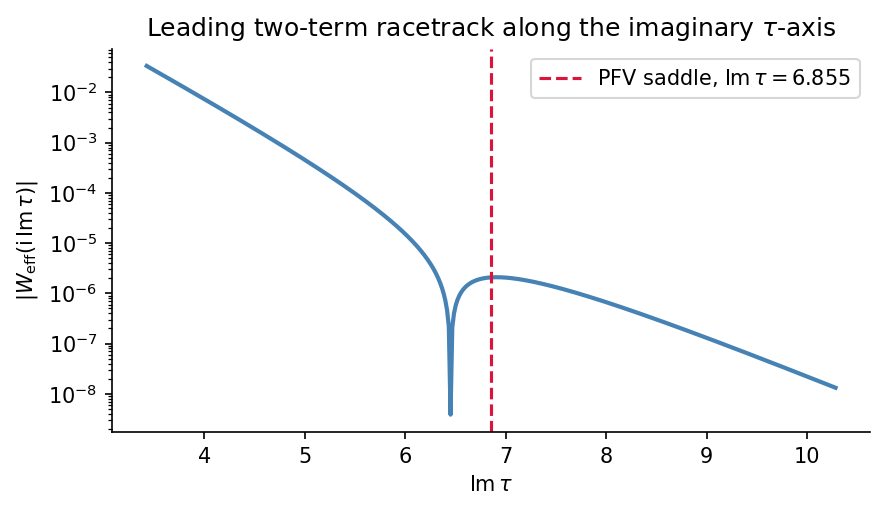

In [16]:
tau_im_grid = np.linspace(0.5 * tau.imag, 1.5 * tau.imag, 400)
Weff = c1  * np.exp(2j * np.pi * p1 * 1j * tau_im_grid) + \
       c2_pref * np.exp(2j * np.pi * p2 * 1j * tau_im_grid)

fig, ax = plt.subplots(figsize=(6, 3.5),dpi=150)
ax.semilogy(tau_im_grid, np.abs(Weff), lw=2, color="steelblue")
ax.axvline(float(tau.imag), color="crimson", ls="--", lw=1.5,
           label=fr"PFV saddle, $\mathrm{{Im}}\,\tau = {float(tau.imag):.3f}$")
ax.set_xlabel(r"$\mathrm{Im}\,\tau$")
ax.set_ylabel(r"$|W_{\rm eff}(\mathrm{i}\,\mathrm{Im}\,\tau)|$")
ax.set_title(r"Leading two-term racetrack along the imaginary $\tau$-axis")
ax.legend()
sn.despine()
plt.tight_layout()
plt.show()

### Term-by-term decay of the racetrack

The two-term picture above is a leading approximation. The full racetrack effective superpotential along the PFV line $z^a=p^a\tau$ is the GV sum
$$
W_{\mathrm{eff}}(\tau)
 \;=\;
 -\frac{1}{(2\pi)^2}
 \sum_{\widetilde{\mathbf q}\in\mathcal{M}(\widetilde X)}
 n_{\widetilde{\mathbf q}}\,
 (\widetilde{\mathbf q}\!\cdot\! M)\,
 \operatorname{Li}_2\!\bigl(\mathrm{e}^{2\pi\mathrm{i}\,(\widetilde{\mathbf q}\cdot p)\,\tau}\bigr) .
$$
We evaluate every term at the numerical PFV solution $\tau$ found above, sort them by absolute magnitude, and plot the decay. The leading-instanton cancellation that produces an exponentially small $|W_0|$ shows up as a $\gtrsim$ five-orders-of-magnitude gap between the leading two terms (which nearly cancel) and the rest of the sum.

rank           q       n_q     q.M     q.p        |term|        Re(term)
   0      (0, 1)         3      50   0.300     9.283e-06  -9.283e-06
   1      (1, 0)       540     -16   0.400     7.201e-06  +7.201e-06
   2      (0, 2)        -6     100   0.600     9.072e-11  +9.072e-11
   3      (1, 1)     -1080      34   0.700     7.477e-11  +7.477e-11
   4      (2, 0)       540     -32   0.800     4.739e-13  +4.739e-13
   5      (0, 3)        27     150   0.900     1.496e-15  -1.496e-15
   6      (1, 2)      2700      84   1.000     1.128e-15  -1.128e-15
   7      (2, 1)    143370      18   1.100     1.729e-16  -1.729e-16
   8      (0, 4)      -192     200   1.200     3.465e-20  +3.465e-20
   9      (1, 3)    -17280     134   1.300     2.814e-20  +2.814e-20
  10      (3, 0)       540     -48   1.200     2.339e-20  +2.339e-20
  11      (2, 2)   -574560      68   1.400     6.396e-21  +6.396e-21

|sum of all terms|              = 2.081e-06
|W_0| from model.superpotential = 2.081e-06


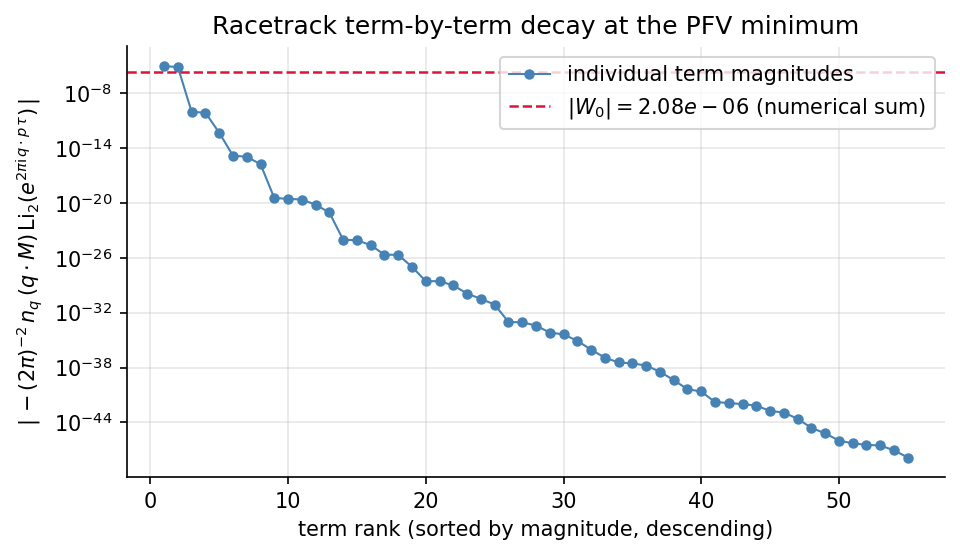

In [17]:
# Li_2 via the defining series. Valid for |z| <= 1, which holds here since
# Re(tau) ~ 0, Im(tau) > 0, and q.p > 0 for all charges in the Mori cone.
def Li2(z, tol=1e-22, max_iter=2000):
    z = np.asarray(z, dtype=complex)
    out = np.zeros_like(z)
    term = z.copy()
    for k in range(1, max_iter + 1):
        out = out + term / (k * k)
        term = term * z
        if np.max(np.abs(term)) < tol:
            break
    return out

# Evaluate every term in the W_eff sum at the numerical PFV solution.
tau_val = complex(tau)
M_arr   = np.asarray(M_flux)
q_dot_p = gv_charges @ p_a
q_dot_M = gv_charges @ M_arr
z_arg   = np.exp(2j * np.pi * q_dot_p * tau_val)
terms   = -1.0 / (2 * np.pi) ** 2 * gv_invariants * q_dot_M * Li2(z_arg)
abs_terms = np.abs(terms)

# Rank by magnitude, descending.
order_desc   = np.argsort(-abs_terms)[:-10]
sorted_terms = terms[order_desc]
sorted_abs   = abs_terms[order_desc]

# Tabular print of the top dozen.
print(f"{'rank':>4}  {'q':>10}  {'n_q':>8}  {'q.M':>6}  {'q.p':>6}  "
      f"{'|term|':>12}  {'Re(term)':>14}")
for rank in range(min(12, len(sorted_terms))):
    idx = order_desc[rank]
    q   = tuple(int(x) for x in gv_charges[idx])
    n   = int(gv_invariants[idx])
    qM  = int(q_dot_M[idx])
    qp  = float(q_dot_p[idx])
    t   = complex(sorted_terms[rank])
    print(f"{rank:>4}  {str(q):>10}  {n:>8}  {qM:>6}  {qp:>6.3f}  "
          f"{sorted_abs[rank]:>12.3e}  {t.real:>+.3e}")

print()
print(f"|sum of all terms|              = {abs(np.sum(terms)):.3e}")
print(f"|W_0| from model.superpotential = {abs(W0):.3e}")

# Plot the decay.
fig, ax = plt.subplots(figsize=(6.5, 3.8),dpi=150)
ax.semilogy(np.arange(1, len(sorted_abs) + 1), sorted_abs,
            "o-", color="steelblue", markersize=4, lw=1,
            label="individual term magnitudes")
ax.axhline(abs(W0), color="crimson", ls="--", lw=1.2,
           label=fr"$|W_0|={abs(W0):.2e}$ (numerical sum)")
ax.set_xlabel("term rank (sorted by magnitude, descending)")
ax.set_ylabel(r"$|\,-(2\pi)^{-2}\,n_q\,(q\cdot M)\,\mathrm{Li}_2(e^{2\pi\mathrm{i}\,q\cdot p\,\tau})\,|$")
ax.set_title("Racetrack term-by-term decay at the PFV minimum")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="upper right")
sn.despine()
plt.tight_layout()
plt.show()

## Takeaways

From a single Kreuzer--Skarke polytope and four integers $(M, K) = ((-16, 50), (3, -4))$ the demo has:

- built `cy` from `fetch_polytopes` and confirmed that the resulting `FluxEFT` agrees with the stored `model_ID=1` on the four prepotential ingredients `intnums`, `c2`, `a_matrix`, `b_vector` (otherwise the rest is unrelated to the displayed geometry);
- checked the PFV integrality conditions $R_a=\widetilde a_{ab}M^b\in\mathbb Z$, $R_0=\widetilde b_a M^a\in\mathbb Z$ **before** the JAXVacua-internal `pfv_to_flux` was trusted;
- solved the F-term equations and reported $|W_0|$, the tadpole $N_{\rm flux}$, and $|DW|$ at the solution, with explicit assertions on each;
- verified the PFV line $z^a = p^a\tau$ to machine precision;
- extracted the leading racetrack exponents $p_1, p_2$ (rationals, **not** integers — cf.\ lecture 2 remark below \eqref{eq:racetrack}) and prefactors $c, A$ from the leading mirror GV invariants, and visualised the racetrack along the imaginary $\tau$-axis.

The full pipeline is auditable end-to-end: each step is either derived from displayed CYTools data or pinned by an assertion against the lecture's analytic statement. **None of the steps depend on a hidden internal dataset.**

### Further reading

- [arXiv:1912.10047](https://arxiv.org/abs/1912.10047) — Demirtas--Kim--McAllister--Moritz, the primary source for this construction.
- [arXiv:2303.00757](https://arxiv.org/abs/2303.00757) — Demirtas--Kim--McAllister--Rios--Tascon: computational mirror symmetry for the period machinery used inside the model.
- TASI 2024 lectures [arXiv:2512.17095](https://arxiv.org/abs/2512.17095) for the same example presented in companion physics-side notation.
- The JAXVacua tutorial `01_basics/3_cytools_interface.ipynb` for the more general CYTools-interface workflow.
- Lecture 2, §\ref{ssec:L2-smallW0}, for the theoretical statement.

## Beyond LCS: a user-supplied prepotential at the K-point of $X_{3,3}$

So far the entire demo has lived deep inside the large-complex-structure (LCS) patch, where the worldsheet-instanton tower is controlled by genus-zero Gopakumar--Vafa invariants and the DKMM perturbatively-flat-vacuum (PFV) construction applies in its textbook form. JAXVacua, however, accepts an arbitrary user-supplied prepotential through `FluxVacuaFinder(..., prepotential_input=F, limit=None)`, which lets us probe other regimes of moduli space — provided we know the prepotential there analytically.

As a clean, fully closed-form test case we instantiate the **K-point boundary** of the one-modulus hypergeometric family $X_{3,3}$ from [arXiv:2306.01059](https://arxiv.org/abs/2306.01059), where the rigid period $\tau_K = \mathrm{e}^{2\pi\mathrm{i}/3}$ and a finite series in $s=(X^1-\tau_K\,X^0)/X^0$ replace the LCS instanton sum.

The point of this section is **not** to claim a PFV-style theorem at the K-point — that hierarchy is specific to LCS — but to exhibit the same `DW_x` / `dDW_x` Newton machinery operating on a qualitatively different prepotential, and to be explicit about what changes (symplectic basis, validity domain, truncation in $s$ rather than in instanton degree) and what breaks (`pfv_to_flux`, `pfv_to_moduli`, the racetrack formula). Treat the converged $|W_0|$ here as a stress-test of the API, not as a phenomenological number on the same footing as the DKMM result above.

### What changes, what stays the same

Compared to the LCS section above, leaving LCS for the K-point changes three things and leaves one thing alone:

| Quantity | LCS / DKMM (above) | K-point / $X_{3,3}$ (below) |
|---|---|---|
| Prepotential | $F_0 = F_{\rm poly} + F_{\rm inst}$ with GV-tower instantons | finite series $F_0+sF_1+s^2F_2+s^3F_3$ in $s$ near $\tau_K$ |
| Symplectic basis | canonical PFV flux ansatz $(R_0, R_a, 0, M^a)^\top$ | no canonical structure; arbitrary integer 4-vectors $f, h$ |
| Truncation parameter | `maximum_degree` (GV degree) | order in $s$ around $\tau_K$ |
| Newton machinery | `DW_x`, `dDW_x`, `_convert_real_to_complex`, `scipy.optimize.root('hybr')` | **identical** |

In particular: **`pfv_to_flux`, `pfv_to_moduli`, the racetrack formula, and the `Li2` helper from the term-decay cell are LCS-specific** and are *not* called in this section.

In [18]:
from jaxvacua.hypergeometric_models import HypergeometricModels, make_prepot_Kpoint

# List available models + the limits supported for X33.
print("available models  :", HypergeometricModels.list())
print("limits for X33    :", HypergeometricModels.available_limits("X33"))

# The K-point boundary data of arXiv:2306.01059.
bd_K = HypergeometricModels.boundary_data("X33", "Kpoint")
print("\nboundary data for X33 K-point:")
for k, v in bd_K.items():
    print(f"  {k:>15s} = {v}")

# tau_K is a fixed transcendental: NOT a modulus, NOT the axio-dilaton tau.
tau_K = complex(bd_K["tau"])
print(f"\nrigid CM period  tau_K = {tau_K}")
print(f"check: tau_K - exp(2 pi i / 3) = {tau_K - np.exp(2j*np.pi/3):.2e}")

available models  : ['108a', '144', '2.17', '2.62', '3.7', '4.47', '864', 'F1', 'M', 'X10', 'X322', 'X33', 'X42', 'X44', 'X5', 'X62', 'X66', 'X8']
limits for X33    : ['LCS', 'Kpoint']

boundary data for X33 K-point:
              tau = (-0.5+0.8660254037844386j)
            gamma = 0.16666666666666666
            delta = 0.3333333333333333
                a = 2
                b = 1
                c = 2
            Bnorm = -0.45032516661820277
              Lf1 = 0.8603521799468205
               B1 = -0.45032516661820277
               B2 = 0.0
               B3 = 0.0
             Bhat = {1: 1.0, 4: -0.5, 7: 2.5567295918367345}
     modular_form = 27.3.b.a

rigid CM period  tau_K = (-0.5+0.8660254037844386j)
check: tau_K - exp(2 pi i / 3) = -1.67e-16-1.11e-16j


In [19]:
# Build the FluxVacuaFinder at the K-point.
# High-level path: HypergeometricModels.build ships the precomputed prepotential closure.
m_K = HypergeometricModels.build("X33", limit="Kpoint", Q=5)

print(f"type             : {type(m_K).__name__}")
print(f"h12              : {m_K.h12}")
print(f"Q (tadpole bound): {m_K.Q()}")
print(f"limit            : {m_K.periods.limit}")

# Sanity check: confirm the model is actually using a user-supplied prepotential,
# NOT the GV-LCS construction.  (limit='LCS' would silently override the closure.)
assert m_K.periods.limit == "Kpoint", \
    "The model is not at the K-point — check the limit= argument."
print("\nlimit assertion passes: this model uses the user-supplied K-point prepotential.")

type             : FluxVacuaFinder
h12              : 1
Q (tadpole bound): 5
limit            : Kpoint

limit assertion passes: this model uses the user-supplied K-point prepotential.


/Users/andreasschachner/Software/GitHub/jax-work/jaxvacua/jaxvacua/periods.py:397: UserWarning: Implementation for general input periods not tested!
  warnings.warn("Implementation for general input periods not tested!")


### Symplectic positivity sanity check

Before solving any F-term equation, validate that the model is in the regime where the Kähler potential $K_{\rm cs}=-\log(-\mathrm{i}\int_X\Omega\wedge\bar\Omega)$ is well defined. In symplectic language this is the requirement
$$
\mathrm{i}\,\Pi^{\top}\Sigma\,\bar\Pi \;>\; 0 ,
$$
which is the only universal check that the user-supplied prepotential and the chosen patch are mutually compatible. We evaluate it at a representative point $z = \tau_K + 0.1\,\mathrm{i}$, deep inside the validity disc $|s|=|z-\tau_K|\le 0.1$ of the K-point expansion.

In [20]:
Sigma_K = np.asarray(m_K.periods.sigma)
print(f"symplectic pairing Sigma =\n{Sigma_K}")

# Pick a point inside the K-point validity disc: z = tau_K + 0.1 i,  so |s| = 0.1.
z_test  = jnp.array([tau_K + 0.1j])
Pi_test = np.asarray(m_K.period_vector(z_test))
print(f"\nperiod vector Pi at z = tau_K + 0.1 i:\n  {Pi_test}")

# i * Pi^T Sigma conj(Pi).  Use Pi^T (no conjugate on the left) and Sigma . conj(Pi):
pairing = 1j * Pi_test @ Sigma_K @ np.conj(Pi_test)
print(f"\ni * Pi^T Sigma conj(Pi) = {pairing}")
print(f"  real part : {pairing.real:.6f}   (must be > 0)")
print(f"  imag part : {pairing.imag:.2e}   (must be ~ 0)")

assert pairing.real > 0,            "Kähler potential ill-defined: i Pi^T Sigma conj(Pi) <= 0."
assert abs(pairing.imag) < 1e-10,   "Symplectic pairing has a non-trivial imaginary part."
print("\nsymplectic positivity check passes at z = tau_K + 0.1 i.")

symplectic pairing Sigma =
[[ 0  0  1  0]
 [ 0  0  0  1]
 [-1  0  0  0]
 [ 0 -1  0  0]]

period vector Pi at z = tau_K + 0.1 i:
  [ 0.55043813-0.24706004j  0.76754293+0.j          1.        +0.j
 -0.5       +0.9660254j ]

i * Pi^T Sigma conj(Pi) = (1.977052003751677+0j)
  real part : 1.977052   (must be > 0)
  imag part : 0.00e+00   (must be ~ 0)

symplectic positivity check passes at z = tau_K + 0.1 i.


### F-term solve at the K-point

We now run the **same** Newton refinement template as the DKMM section, with the same `scipy.optimize.root(method='hybr', jac=m_K.dDW_x)`. The only differences are: a length-$2(h^{2,1}+1) = 4 + 4 = 8$ integer flux vector (since $h^{2,1}=1$ here), and an initial point chosen inside the $|s|\le 0.1$ disc.

The flux vector below was found by a small random search over integer $f, h\in\mathbb Z^4$; we keep it for reproducibility but treat the resulting $|W_0|$ as illustrative, not phenomenological. **There is no PFV theorem here**, so we should not expect an exponentially small $|W_0|$: it will simply be a converged supersymmetric flux vacuum at order $\mathcal O(1)$.

In [21]:
# Integer flux 8-vector  (4 components for F_3, 4 for H_3) found by a small search.
# Same shape as the LCS flux above, but no PFV-style canonical block structure.
flux_K = jnp.array([-1.0, -2.0, -2.0, -2.0,  1.0,  1.0,  1.0,  0.0])

# Initial point: z = tau_K + 0.08 i (inside |s| <= 0.1) and tau (axio-dilaton)
# at 2 i (weak coupling g_s ~ 0.5).  These were tuned together with flux_K to land
# in the basin of attraction of a converged SUSY vacuum; arbitrary fluxes will
# generically NOT converge.
z0_K   = tau_K + 0.08j
tau0_K = 2.0j
x0_K   = m_K._convert_complex_to_real(
            jnp.array([z0_K]), jnp.array([jnp.conj(z0_K)]),
            tau0_K, jnp.conj(tau0_K))

initial_residual_K = float(jnp.linalg.norm(m_K.DW_x(x0_K, flux_K)))
print(f"initial |DW|  = {initial_residual_K:.3e}")

tic = time.perf_counter()
res_K = root(
    m_K.DW_x,
    x0=np.asarray(x0_K),
    args=(np.asarray(flux_K),),
    method="hybr",
    jac=m_K.dDW_x,
    tol=1e-12,
)
elapsed_K = time.perf_counter() - tic

x_sol_K = jnp.asarray(res_K.x)
z_K, _, tau_dil_K, _ = m_K._convert_real_to_complex(x_sol_K)
residual_K = float(jnp.linalg.norm(m_K.DW_x(x_sol_K, np.asarray(flux_K))))
W0_K       = complex(m_K.superpotential(z_K, tau_dil_K, flux_K))
s_at_sol   = complex(z_K[0]) - tau_K
print(f"\nsolver success = {res_K.success}, nfev = {res_K.nfev}, elapsed = {elapsed_K:.2f}s")
print(f"|DW|_residual  = {residual_K:.3e}")
print(f"z              = {complex(z_K[0]):.6f}")
print(f"s = z - tau_K  = {s_at_sol:.6f}     (|s| = {abs(s_at_sol):.3f})")
print(f"tau (dilaton)  = {complex(tau_dil_K):.6f}")
print(f"g_s = 1/Im tau = {1/tau_dil_K.imag:.3f}")
print(f"|W_0|          = {abs(W0_K):.3e}     (NOT exponentially small: no PFV here)")

# Physical assertions appropriate for a non-PFV vacuum.
assert res_K.success,                                       "scipy.root reported failure."
assert residual_K < 1e-10,                                  f"|DW| = {residual_K:.3e} too large."
assert tau_dil_K.imag > 1.0,                                f"Im(tau) = {tau_dil_K.imag:.2f} not in physical (weak-coupling) regime."
assert abs(s_at_sol) < 0.2,                                 f"|s| = {abs(s_at_sol):.2f} outside the K-point validity disc."
print("\nphysical sanity checks pass: converged SUSY vacuum inside the K-point patch.")

initial |DW|  = 4.117e+00

solver success = True, nfev = 20, elapsed = 1.12s
|DW|_residual  = 1.261e-15
z              = -0.456676+0.891440j
s = z - tau_K  = 0.043324+0.025415j     (|s| = 0.050)
tau (dilaton)  = -2.263630+2.256439j
g_s = 1/Im tau = 0.443
|W_0|          = 5.815e+00     (NOT exponentially small: no PFV here)

physical sanity checks pass: converged SUSY vacuum inside the K-point patch.
